# scroll2 test figure layout test

tests `_create_combined_test_figure` using the scroll2 mask as stand-in predictions.
no model needed. verifies the 2-col depth mosaic layout for the scroll2 region.

region: x=3080..5128 (2048 wide), y=748..1772 (1024 tall) → 64 × 32 tiles at tile_size=32.
with depth=8 and z_step=4 over a 500-slice volume, a real run produces ~123 depth blocks.
this notebook simulates a representative subset to stress-test the grid.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import cv2

TILE = 32

# standalone copy of _create_combined_test_figure — no class needed
def create_combined_test_figure(all_data, test_type="Scroll2"):
    """2-col mosaic of per-depth prediction maps, matching visualizer output.

    all_data: list of (pred_map, d_start, d_end)
    test_type: used to pick row height multiplier (scroll1 gets 7, others get 3)
    """
    cols = 2
    n_blocks = len(all_data)
    rows = (n_blocks + cols - 1) // cols

    fig_w = 8
    h_mult = 7 if test_type == "Test" else 3
    fig_h = h_mult * rows

    fig, axes = plt.subplots(rows, cols, figsize=(fig_w, fig_h))
    if rows == 1 and cols == 1:
        axes = np.array([[axes]])
    elif rows == 1:
        axes = axes.reshape(1, -1)
    elif cols == 1:
        axes = axes.reshape(-1, 1)

    for idx, (pred, d_start, d_end) in enumerate(all_data):
        ax = axes[idx // cols, idx % cols]
        ax.imshow(pred, cmap='inferno', vmin=0, vmax=1, aspect='equal')
        ax.set_title(f'Depth Block {d_start}-{d_end}', fontsize=9)
        ax.axis('off')

    # blank out any trailing cell when n_blocks is odd
    for idx in range(n_blocks, rows * cols):
        axes[idx // cols, idx % cols].axis('off')

    plt.subplots_adjust(wspace=0.05, hspace=0.05,
                        left=0.05, right=0.95,
                        top=0.95, bottom=0.05)
    return fig


def mask_to_tiled(mask_path, y0, y1, x0, x1, tile=TILE):
    """load mask, crop to region, block-average to tile resolution"""
    raw = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    assert raw is not None, f"could not read {mask_path}"
    crop = raw[y0:y1, x0:x1].astype(np.float32) / 255.0
    h_t = (y1 - y0) // tile
    w_t = (x1 - x0) // tile
    tiled = crop[:h_t * tile, :w_t * tile].reshape(h_t, tile, w_t, tile).mean(axis=(1, 3))
    return tiled.astype(np.float32)


def make_depth_blocks(base_map, d_start_vals, depth=8, noise_std=0.03, seed=42):
    """synthesize one prediction map per depth start value.

    intensity varies with depth to mimic real ink-layer falloff;
    the peak is placed at the center of the range.
    """
    rng = np.random.default_rng(seed)
    n = len(d_start_vals)
    mid = n / 2.0
    all_data = []
    for i, d_start in enumerate(d_start_vals):
        # bell-curve scale so middle depths look brighter
        dist = abs(i - mid) / max(mid, 1)
        scale = 0.85 - 0.45 * dist
        pred = np.clip(base_map * scale + rng.normal(0, noise_std, base_map.shape), 0, 1).astype(np.float32)
        all_data.append((pred, d_start, d_start + depth))
    return all_data


print("helpers ready")


helpers ready


## load scroll2 mask and crop to the target region

scroll2 region: x=3080..5128 (2048 wide), y=748..1772 (1024 tall)
→ 64 wide × 32 tall tile map — landscape 2:1 aspect

full mask shape: (2806, 8499)  (H x W px)
crop region: y=748..1772, x=3080..5128
tiled map: 32 h × 64 w tiles  aspect=2.00


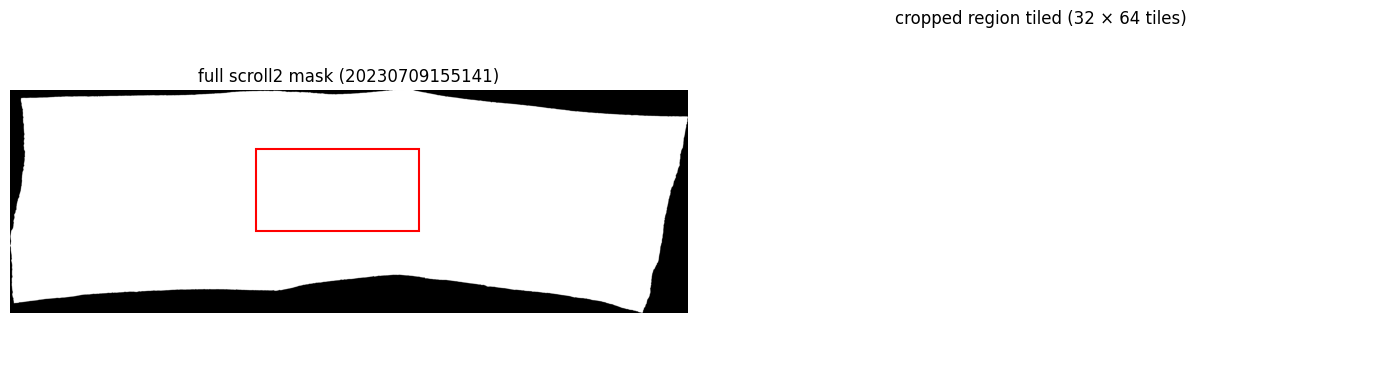

In [2]:
SCROLL2_MASK = "./masks/20230709155141.png"

# region defined in _load_scroll2_region
Y0, Y1 = 748, 748 + 1024   # height: 1024 px → 32 tiles
X0, X1 = 3080, 3080 + 2048 # width:  2048 px → 64 tiles

raw_mask = cv2.imread(SCROLL2_MASK, cv2.IMREAD_GRAYSCALE)
assert raw_mask is not None, f"mask not found at {SCROLL2_MASK}"

print(f"full mask shape: {raw_mask.shape}  (H x W px)")
print(f"crop region: y={Y0}..{Y1}, x={X0}..{X1}")

base = mask_to_tiled(SCROLL2_MASK, Y0, Y1, X0, X1)
h_t, w_t = base.shape
print(f"tiled map: {h_t} h × {w_t} w tiles  aspect={w_t/h_t:.2f}")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 4))
a1.imshow(raw_mask, cmap='gray')
a1.set_title("full scroll2 mask (20230709155141)")
a1.add_patch(plt.Rectangle((X0, Y0), X1 - X0, Y1 - Y0,
             edgecolor='red', facecolor='none', linewidth=1.5))
a1.axis('off')

a2.imshow(base, cmap='gray', vmin=0, vmax=1)
a2.set_title(f"cropped region tiled ({h_t} × {w_t} tiles)")
a2.axis('off')
plt.tight_layout()
plt.show()


## simulate depth blocks

a real run against the 500-slice scroll2 zarr with depth=8 and z_step=4 produces ~123 depth blocks.
here we simulate 20 blocks (d_start = 0, 4, 8, ..., 76) — enough to fill 10 rows in the 2-col grid
and verify the mosaic layout without running inference.

In [3]:
DEPTH = 8
Z_STEP = 4
N_BLOCKS = 20  # representative subset; real run ~= (500 - 8) // 4 = 123 blocks

d_start_vals = [i * Z_STEP for i in range(N_BLOCKS)]
all_data = make_depth_blocks(base, d_start_vals, depth=DEPTH)

print(f"simulated {len(all_data)} depth blocks")
print(f"d_start range: {d_start_vals[0]} .. {d_start_vals[-1]}")
print(f"grid layout:   {(len(all_data) + 1) // 2} rows × 2 cols")
print(f"tile map per block: {h_t} h × {w_t} w  (landscape aspect {w_t/h_t:.2f})")


simulated 20 depth blocks
d_start range: 0 .. 76
grid layout:   10 rows × 2 cols
tile map per block: 32 h × 64 w  (landscape aspect 2.00)


## scroll2 test figure (20 depth blocks, 10 rows × 2 cols)

layout check passed: 10 rows × 2 cols, all 20 depth labels present
figsize: 8.00 w × 30.00 h inches


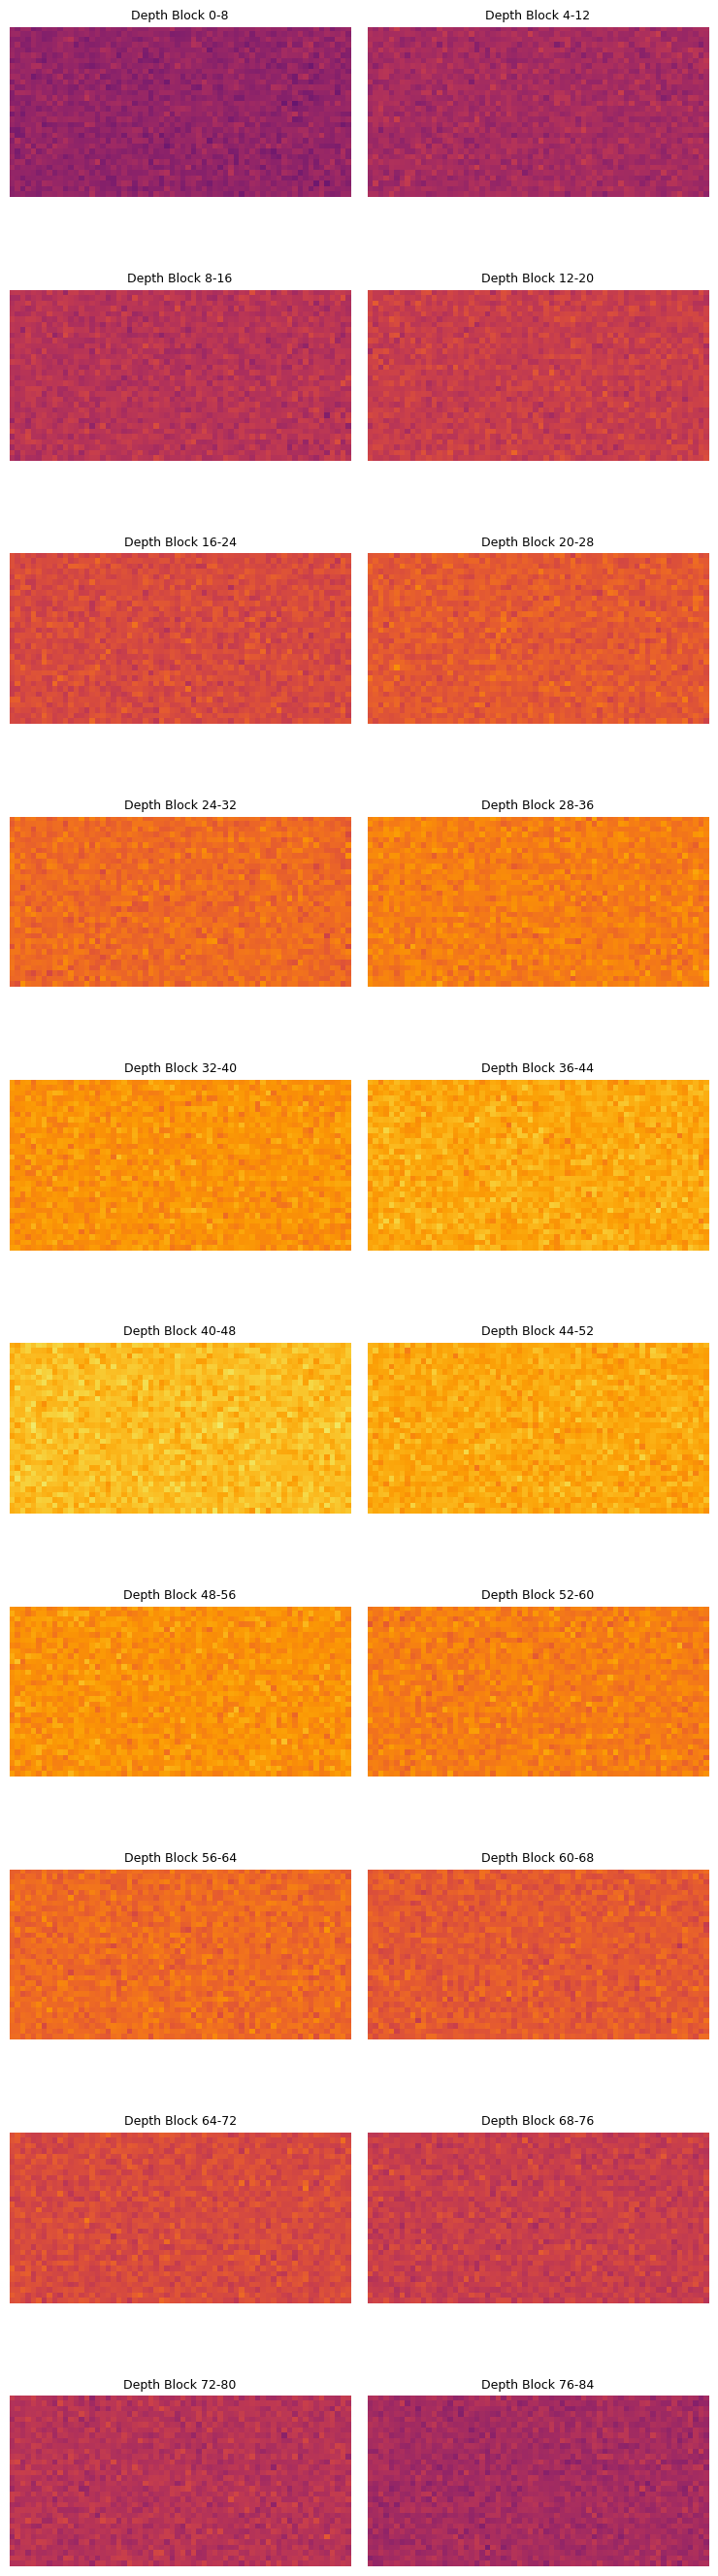

In [4]:
fig = create_combined_test_figure(all_data, test_type="Scroll2")

# layout checks
axes_flat = fig.get_axes()
cols = 2
rows = (N_BLOCKS + cols - 1) // cols
assert len(axes_flat) == rows * cols, f"expected {rows * cols} axes, got {len(axes_flat)}"
for i, (_, d_start, d_end) in enumerate(all_data):
    title = axes_flat[i].get_title()
    assert f"{d_start}-{d_end}" in title, f"depth label missing in cell {i}: '{title}'"
print(f"layout check passed: {rows} rows × {cols} cols, all {N_BLOCKS} depth labels present")

w_in, h_in = fig.get_size_inches()
print(f"figsize: {w_in:.2f} w × {h_in:.2f} h inches")
plt.show()


## odd block count — trailing cell should be blank

verify the grid handles an odd number of depth blocks cleanly (last cell turned off).

odd-count check passed: 7 blocks in 4×2 grid, last cell is blank
figsize: 8.00 w × 12.00 h inches


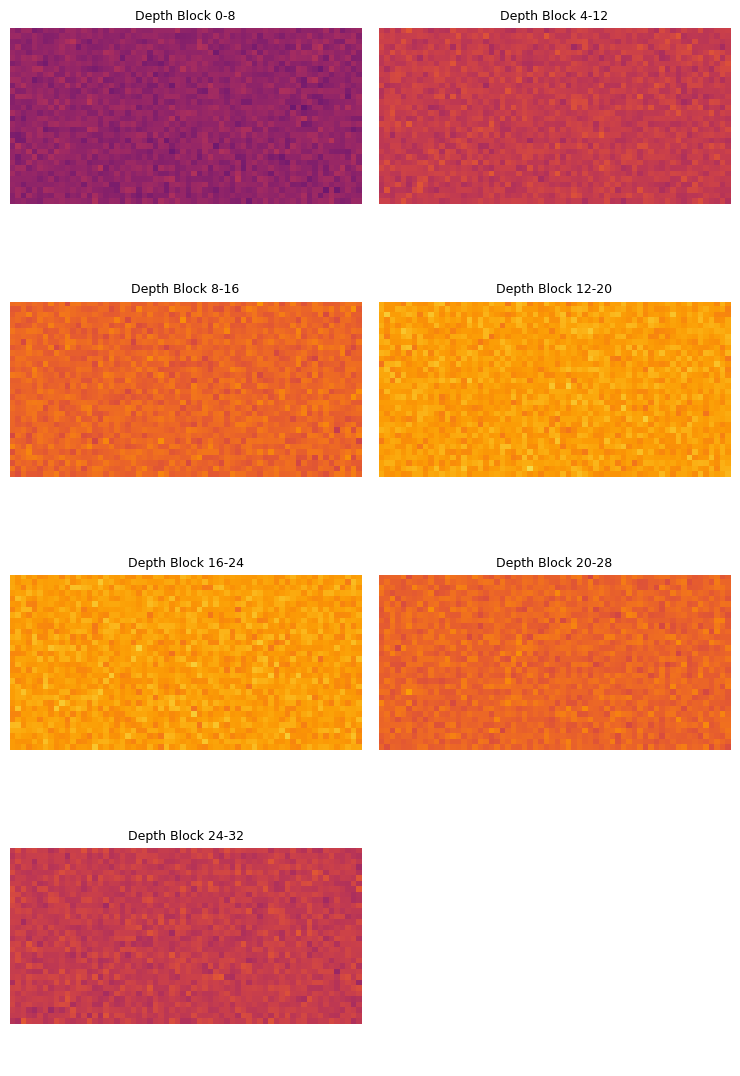

In [5]:
odd_data = make_depth_blocks(base, d_start_vals[:7], depth=DEPTH)  # 7 blocks → 4 rows, last cell blank
fig_odd = create_combined_test_figure(odd_data, test_type="Scroll2")

axes_odd = fig_odd.get_axes()
last_ax = axes_odd[-1]
assert not last_ax.get_visible() or not last_ax.axison, "trailing cell should have axis off"
print(f"odd-count check passed: 7 blocks in 4×2 grid, last cell is blank")

w_in, h_in = fig_odd.get_size_inches()
print(f"figsize: {w_in:.2f} w × {h_in:.2f} h inches")
plt.show()
